In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, str(Path("..").resolve()))
from src.viz import *
apply_style()

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

PROC = Path("..") / "data" / "processed"
fct_orders = pd.read_parquet(PROC / "fct_orders.parquet")
fct_items = pd.read_parquet(PROC / "fct_order_items.parquet")

orders = fct_orders[fct_orders.is_delivered & fct_orders.in_window].copy()
items = fct_items[(fct_items.is_delivered == True) & (fct_items.in_window == True)].copy()

print(f"orders   : {len(orders):,}  (delivered, Jan-2017..Aug-2018)")
print(f"items    : {len(items):,}")
print(f"revenue  : R$ {orders.order_revenue.sum():,.2f}")
print(f"customers: {orders.customer_unique_id.nunique():,}")

orders["order_period"] = pd.to_datetime(orders.order_purchase_timestamp).dt.to_period("M")
cohort_of = orders.groupby("customer_unique_id").order_period.min().rename("cohort")
orders = orders.join(cohort_of, on="customer_unique_id")
orders["cohort_age"] = (orders.order_period - orders.cohort).apply(lambda x: x.n)

cohort_size = orders.groupby("cohort").customer_unique_id.nunique()
WINDOW_END_PERIOD = pd.Period("2018-08", freq="M")

print(f"cohorts: {len(cohort_size)} months, {cohort_size.sum():,} customers")
display(cohort_size.rename("new_customers").to_frame().T)

orders   : 96,211  (delivered, Jan-2017..Aug-2018)
items    : 109,880
revenue  : R$ 13,181,027.13
customers: 93,104
cohorts: 20 months, 93,104 customers


cohort,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08
new_customers,718,1628,2503,2257,3451,3037,3753,4057,4005,4328,7061,5338,6843,6288,6775,6582,6508,5879,5949,6144


In [2]:
cohort_tbl = pd.DataFrame({
    "new_customers": cohort_size,
    "revenue": orders.groupby("cohort").order_revenue.sum(),
})
cohort_tbl["revenue_per_customer"] = cohort_tbl.revenue / cohort_tbl.new_customers
cohort_tbl["months_observed"] = [(WINDOW_END_PERIOD - c).n for c in cohort_tbl.index]
display(cohort_tbl.round(2))

print(f"largest cohort : {cohort_size.idxmax()} ({cohort_size.max():,} customers — Black Friday)")
print(f"smallest cohort: {cohort_size.idxmin()} ({cohort_size.min():,})")
print(f"\nrevenue per customer range: R$ {cohort_tbl.revenue_per_customer.min():,.2f} "
      f"– R$ {cohort_tbl.revenue_per_customer.max():,.2f}")
print(f"  std dev: R$ {cohort_tbl.revenue_per_customer.std():,.2f} "
      f"(coefficient of variation {cohort_tbl.revenue_per_customer.std()/cohort_tbl.revenue_per_customer.mean()*100:.1f}%)")

,new_customers,revenue,revenue_per_customer,months_observed
cohort,,,,
2017-01,718,"114,607.34",159.62,19
2017-02,1628,"239,788.46",147.29,18
2017-03,2503,"371,645.15",148.48,17
2017-04,2257,"351,596.78",155.78,16
2017-05,3451,"502,508.72",145.61,15
2017-06,3037,"434,368.18",143.03,14
2017-07,3753,"491,075.52",130.85,13
2017-08,4057,"566,249.59",139.57,12
2017-09,4005,"613,931.98",153.29,11


largest cohort : 2017-11 (7,061 customers — Black Friday)
smallest cohort: 2017-01 (718)

revenue per customer range: R$ 130.85 – R$ 159.62
  std dev: R$ 8.01 (coefficient of variation 5.6%)


In [3]:
counts = orders.pivot_table(index="cohort", columns="cohort_age",
                            values="customer_unique_id", aggfunc="nunique")
retention = counts.div(cohort_size, axis=0) * 100

print("CUSTOMER COUNTS by cohort age (month 0 = acquisition month)")
display(counts.iloc[:, :9])

print("RETENTION % by cohort age")
display(retention.iloc[:, :9].round(2))

CUSTOMER COUNTS by cohort age (month 0 = acquisition month)


cohort_age,0,1,2,3,4,5,6,7,8
cohort,,,,,,,,,
2017-01,718.00,2.00,2.00,1.00,3.00,1.00,3.00,1.00,1.00
2017-02,"1,628.00",3.00,5.00,2.00,7.00,2.00,4.00,3.00,2.00
2017-03,"2,503.00",11.00,9.00,10.00,9.00,4.00,4.00,8.00,8.00
2017-04,"2,257.00",14.00,5.00,4.00,6.00,6.00,8.00,7.00,7.00
2017-05,"3,451.00",16.00,16.00,10.00,10.00,11.00,14.00,5.00,9.00
2017-06,"3,037.00",15.00,12.00,13.00,9.00,12.00,11.00,7.00,4.00
2017-07,"3,753.00",20.00,13.00,9.00,11.00,8.00,12.00,4.00,7.00
2017-08,"4,057.00",28.00,14.00,11.00,14.00,21.00,12.00,11.00,6.00
2017-09,"4,005.00",28.00,22.00,11.00,18.00,9.00,9.00,10.00,11.00


RETENTION % by cohort age


cohort_age,0,1,2,3,4,5,6,7,8
cohort,,,,,,,,,
2017-01,100.00,0.28,0.28,0.14,0.42,0.14,0.42,0.14,0.14
2017-02,100.00,0.18,0.31,0.12,0.43,0.12,0.25,0.18,0.12
2017-03,100.00,0.44,0.36,0.40,0.36,0.16,0.16,0.32,0.32
2017-04,100.00,0.62,0.22,0.18,0.27,0.27,0.35,0.31,0.31
2017-05,100.00,0.46,0.46,0.29,0.29,0.32,0.41,0.14,0.26
2017-06,100.00,0.49,0.40,0.43,0.30,0.40,0.36,0.23,0.13
2017-07,100.00,0.53,0.35,0.24,0.29,0.21,0.32,0.11,0.19
2017-08,100.00,0.69,0.35,0.27,0.35,0.52,0.30,0.27,0.15
2017-09,100.00,0.70,0.55,0.27,0.45,0.22,0.22,0.25,0.27


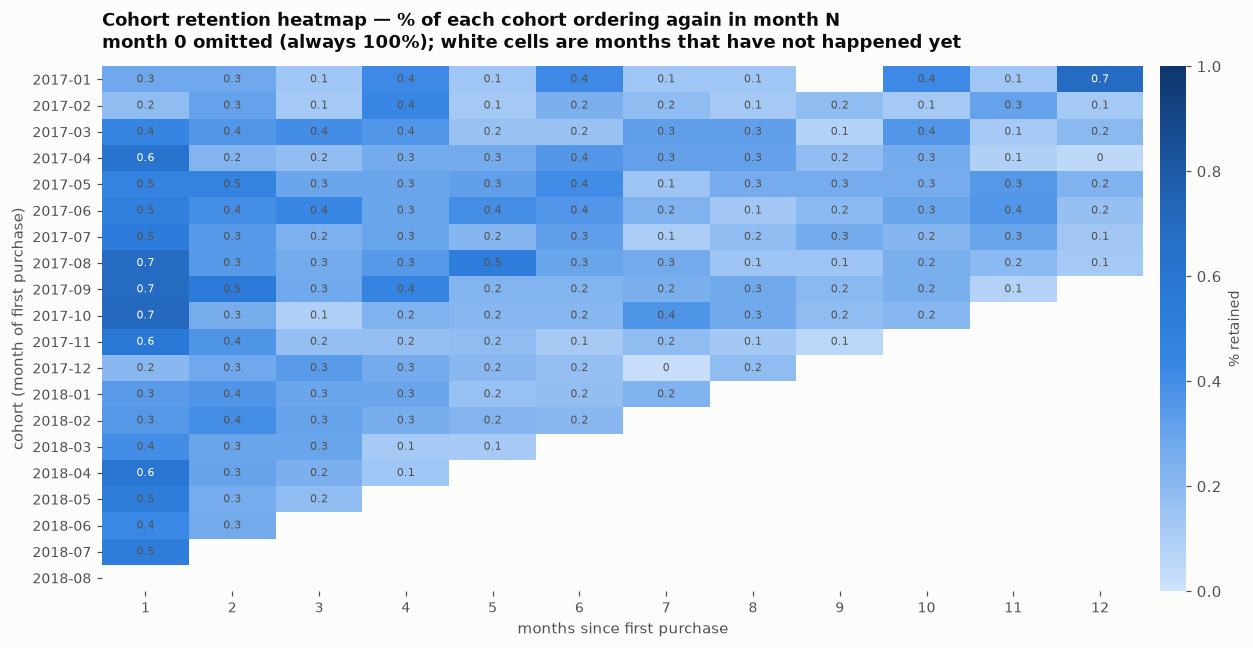

In [4]:
fig, ax = plt.subplots(figsize=(11.5, 6))

plot_data = retention.iloc[:, 1:13]   # drop month 0 (always 100%)
im = ax.imshow(plot_data.values, cmap=SEQ_CMAP, aspect="auto", vmin=0, vmax=1.0)

ax.set_xticks(range(plot_data.shape[1]))
ax.set_xticklabels(plot_data.columns, fontsize=9)
ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels([str(c) for c in plot_data.index], fontsize=9)
ax.set_xlabel("months since first purchase")
ax.set_ylabel("cohort (month of first purchase)")
ax.set_title("Cohort retention heatmap — % of each cohort ordering again in month N\n"
             "month 0 omitted (always 100%); white cells are months that have not happened yet")

for i in range(plot_data.shape[0]):
    for j in range(plot_data.shape[1]):
        v = plot_data.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.1f}" if v >= 0.05 else "0", ha="center", va="center",
                    fontsize=7.5, color="#ffffff" if v > 0.55 else INK_2)

cb = fig.colorbar(im, ax=ax, pad=0.015, fraction=0.025)
cb.set_label("% retained", color=INK_2, fontsize=9)
cb.outline.set_visible(False)
ax.grid(False)
for sp in ax.spines.values():
    sp.set_visible(False)
plt.tight_layout(); plt.show()

In [5]:
avg_retention = retention.mean()
decay = avg_retention.head(13).rename("avg_retention_pct").to_frame()
decay["cohorts_contributing"] = retention.notna().sum().head(13)
decay["pct_of_month_1"] = (decay.avg_retention_pct / avg_retention.iloc[1] * 100).round(1)
display(decay.round(3))

print(f"month 1 retention (avg across cohorts): {avg_retention.iloc[1]:.3f}%")
print(f"month 2: {avg_retention.iloc[2]:.3f}%   month 3: {avg_retention.iloc[3]:.3f}%")
print(f"month 6: {avg_retention.iloc[6]:.3f}%   month 12: {avg_retention.iloc[12]:.3f}%")
print(f"\ndecay from month 1 to month 3: "
      f"{(1 - avg_retention.iloc[3]/avg_retention.iloc[1])*100:.1f}%")

,avg_retention_pct,cohorts_contributing,pct_of_month_1
cohort_age,,,
0,100.00,20,"21,024.80"
1,0.48,19,100.00
2,0.34,18,70.80
3,0.25,17,52.70
4,0.29,16,60.60
5,0.23,15,48.50
6,0.26,14,54.90
7,0.21,13,44.70
8,0.21,12,43.50


month 1 retention (avg across cohorts): 0.476%
month 2: 0.337%   month 3: 0.251%
month 6: 0.261%   month 12: 0.215%

decay from month 1 to month 3: 47.3%


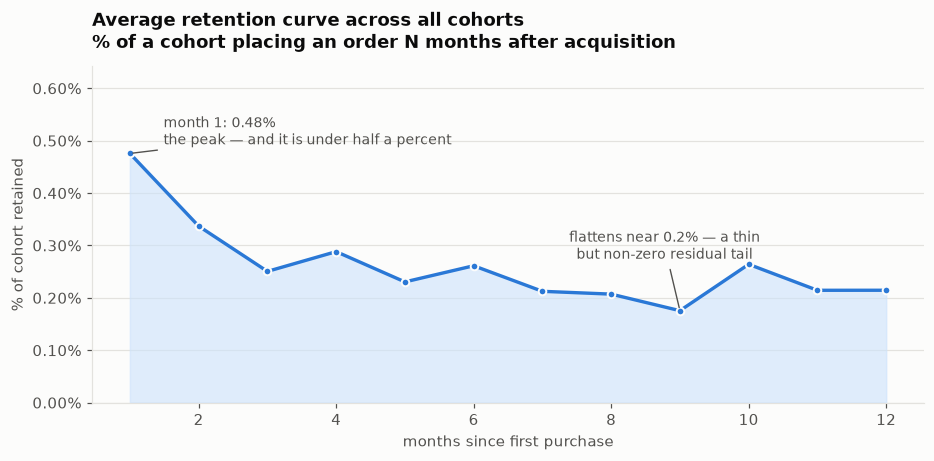

In [6]:
fig, ax = plt.subplots(figsize=(8.6, 4.3))
x = avg_retention.index[1:13]
y = avg_retention.values[1:13]
ax.plot(x, y, color=BLUE, linewidth=2.2, marker="o", markersize=5,
        markeredgecolor=SURFACE, markeredgewidth=1.3)
ax.fill_between(x, 0, y, color=BLUE_RAMP[0], alpha=0.6)

ax.annotate(f"month 1: {y[0]:.2f}%\nthe peak — and it is under half a percent",
            xy=(1, y[0]), xytext=(22, 6), textcoords="offset points",
            fontsize=9, color=INK_2,
            arrowprops=dict(arrowstyle="-", color=INK_2, lw=0.9))
ax.annotate("flattens near 0.2% — a thin\nbut non-zero residual tail",
            xy=(9, y[8]), xytext=(-10, 34), textcoords="offset points",
            fontsize=9, color=INK_2, ha="center",
            arrowprops=dict(arrowstyle="-", color=INK_2, lw=0.9))

ax.set_title("Average retention curve across all cohorts\n% of a cohort placing an order N months after acquisition")
ax.set_xlabel("months since first purchase"); ax.set_ylabel("% of cohort retained")
ax.set_ylim(0, y.max() * 1.35)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis="x", visible=False); despine(ax)
plt.tight_layout(); plt.show()

In [7]:
ever_repeat = (orders.groupby(["cohort", "customer_unique_id"]).size()
               .gt(1).groupby("cohort").mean() * 100)

naive = pd.DataFrame({
    "cohort_size": cohort_size,
    "ever_repeated_pct": ever_repeat,
    "months_observed": [(WINDOW_END_PERIOD - c).n for c in cohort_size.index],
})
display(naive.round(2))

corr = naive.months_observed.corr(naive.ever_repeated_pct)
print(f"correlation between months_observed and ever_repeated_pct: {corr:.4f}")
print("\nThat correlation is the artefact. It says almost all of the apparent difference")
print("between cohorts is explained by how long each has been observed - not by cohort quality.")

,cohort_size,ever_repeated_pct,months_observed
cohort,,,
2017-01,718,7.24,19
2017-02,1628,4.05,18
2017-03,2503,4.83,17
2017-04,2257,4.52,16
2017-05,3451,5.27,15
2017-06,3037,5.30,14
2017-07,3753,4.66,13
2017-08,4057,4.71,12
2017-09,4005,4.52,11


correlation between months_observed and ever_repeated_pct: 0.9165

That correlation is the artefact. It says almost all of the apparent difference
between cohorts is explained by how long each has been observed - not by cohort quality.


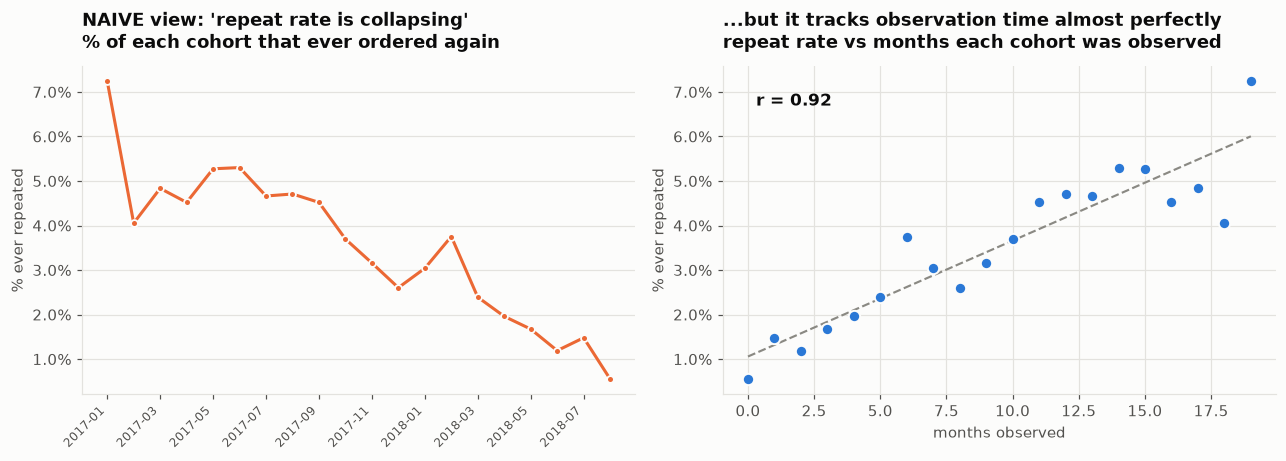

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.3))

ax = axes[0]
ax.plot(range(len(naive)), naive.ever_repeated_pct, color=ORANGE, linewidth=2,
        marker="o", markersize=4.5, markeredgecolor=SURFACE, markeredgewidth=1.2)
ax.set_xticks(range(0, len(naive), 2))
ax.set_xticklabels([str(c) for c in naive.index[::2]], rotation=45, ha="right", fontsize=8)
ax.set_title("NAIVE view: 'repeat rate is collapsing'\n% of each cohort that ever ordered again")
ax.set_ylabel("% ever repeated")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis="x", visible=False); despine(ax)

ax = axes[1]
ax.scatter(naive.months_observed, naive.ever_repeated_pct, s=55, color=BLUE,
           edgecolor=SURFACE, linewidth=1.3, zorder=3)
z = np.polyfit(naive.months_observed, naive.ever_repeated_pct, 1)
xs = np.array([naive.months_observed.min(), naive.months_observed.max()])
ax.plot(xs, np.polyval(z, xs), color=INK_3, linewidth=1.4, linestyle="--")
ax.annotate(f"r = {corr:.2f}", xy=(0.06, 0.88), xycoords="axes fraction",
            fontsize=11, color=INK, fontweight="bold")
ax.set_title("...but it tracks observation time almost perfectly\nrepeat rate vs months each cohort was observed")
ax.set_xlabel("months observed"); ax.set_ylabel("% ever repeated")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
despine(ax)

plt.tight_layout(); plt.show()

In [9]:
HORIZON = 3
eligible = [c for c in cohort_size.index if (WINDOW_END_PERIOD - c).n >= HORIZON]

within = (orders[orders.cohort_age.between(1, HORIZON)]
          .groupby("cohort").customer_unique_id.nunique())
fair = pd.DataFrame({
    "cohort_size": cohort_size.loc[eligible],
    "repeated_within_3mo": within.reindex(eligible).fillna(0),
})
fair["repeat_rate_3mo_pct"] = fair.repeated_within_3mo / fair.cohort_size * 100
display(fair.round(3))

print(f"cohorts compared on equal footing: {len(fair)} (each observed >= {HORIZON} months)")
print(f"3-month repeat rate — mean {fair.repeat_rate_3mo_pct.mean():.3f}%, "
      f"range {fair.repeat_rate_3mo_pct.min():.3f}%–{fair.repeat_rate_3mo_pct.max():.3f}%")

early = fair.head(6).repeat_rate_3mo_pct.mean()
late = fair.tail(6).repeat_rate_3mo_pct.mean()
print(f"\n  first 6 cohorts (2017 H1) : {early:.3f}%")
print(f"  last 6 cohorts  (2018)    : {late:.3f}%")
print(f"  difference                : {late - early:+.3f} pp ({(late/early - 1)*100:+.1f}% relative)")

idx = np.arange(len(fair))
slope, intercept = np.polyfit(idx, fair.repeat_rate_3mo_pct, 1)
print(f"\n  linear trend across cohorts: {slope:+.4f} pp per month")

,cohort_size,repeated_within_3mo,repeat_rate_3mo_pct
cohort,,,
2017-01,718,5,0.70
2017-02,1628,10,0.61
2017-03,2503,29,1.16
2017-04,2257,23,1.02
2017-05,3451,40,1.16
2017-06,3037,37,1.22
2017-07,3753,40,1.07
2017-08,4057,50,1.23
2017-09,4005,58,1.45


cohorts compared on equal footing: 17 (each observed >= 3 months)
3-month repeat rate — mean 1.036%, range 0.614%–1.448%

  first 6 cohorts (2017 H1) : 0.978%
  last 6 cohorts  (2018)    : 0.976%
  difference                : -0.001 pp (-0.1% relative)

  linear trend across cohorts: +0.0058 pp per month


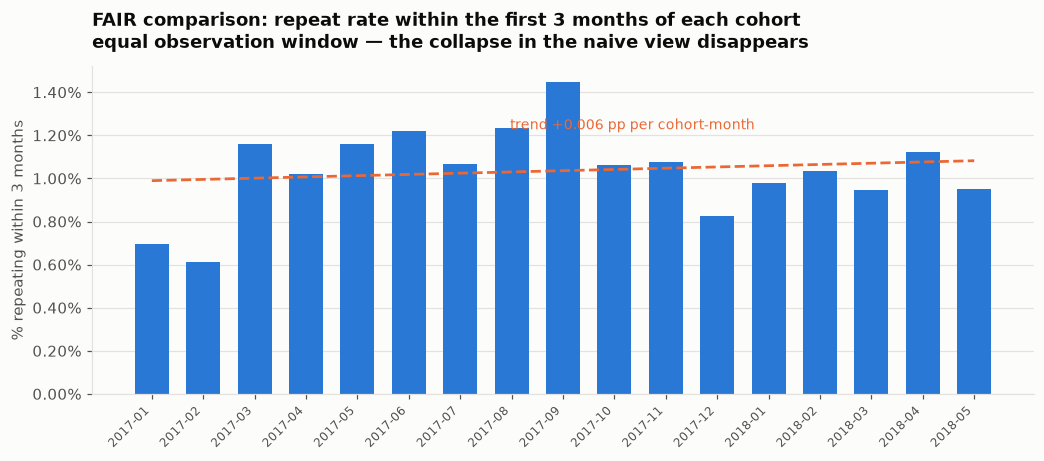

In [10]:
fig, ax = plt.subplots(figsize=(9.6, 4.3))
ax.bar(range(len(fair)), fair.repeat_rate_3mo_pct, color=BLUE, width=0.66)
ax.plot(idx, np.polyval([slope, intercept], idx), color=ORANGE, linewidth=1.8, linestyle="--")
ax.annotate(f"trend {slope:+.3f} pp per cohort-month",
            xy=(len(fair)*0.55, np.polyval([slope, intercept], len(fair)*0.55)),
            xytext=(0, 26), textcoords="offset points", fontsize=9, color=ORANGE, ha="center")
ax.set_xticks(range(len(fair)))
ax.set_xticklabels([str(c) for c in fair.index], rotation=45, ha="right", fontsize=8)
ax.set_title("FAIR comparison: repeat rate within the first 3 months of each cohort\n"
             "equal observation window — the collapse in the naive view disappears")
ax.set_ylabel("% repeating within 3 months")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis="x", visible=False); despine(ax)
plt.tight_layout(); plt.show()

In [11]:
rev_matrix = orders.pivot_table(index="cohort", columns="cohort_age",
                                values="order_revenue", aggfunc="sum")
cohort_first_rev = rev_matrix[0]
rev_retention = rev_matrix.div(cohort_first_rev, axis=0) * 100

print("REVENUE in month N as % of the cohort's month-0 revenue")
display(rev_retention.iloc[:, :7].round(2))

total_later = rev_matrix.drop(columns=0).sum().sum()
total_first = cohort_first_rev.sum()
print(f"\nrevenue in acquisition month : R$ {total_first:,.2f}")
print(f"revenue in all later months  : R$ {total_later:,.2f}")
print(f"share of revenue arriving after the acquisition month: "
      f"{total_later/(total_first+total_later)*100:.2f}%")

REVENUE in month N as % of the cohort's month-0 revenue


cohort_age,0,1,2,3,4,5,6
cohort,,,,,,,
2017-01,100.00,0.07,0.07,0.07,0.18,0.05,0.33
2017-02,100.00,0.19,0.21,0.04,0.42,0.02,0.25
2017-03,100.00,0.38,0.40,0.46,0.28,0.36,0.17
2017-04,100.00,0.78,0.24,0.20,0.31,0.31,0.54
2017-05,100.00,0.31,0.49,0.27,0.22,0.27,0.55
2017-06,100.00,0.42,0.42,0.31,0.30,0.33,0.30
2017-07,100.00,0.55,0.22,0.21,0.19,0.35,0.47
2017-08,100.00,0.78,0.35,0.15,0.27,0.46,0.29
2017-09,100.00,0.50,0.47,0.23,0.48,0.27,0.15



revenue in acquisition month : R$ 12,946,144.85
revenue in all later months  : R$ 234,882.28
share of revenue arriving after the acquisition month: 1.78%


In [12]:
retention.to_parquet(PROC / "cohort_retention_matrix.parquet")

cohort_summary = cohort_tbl.copy()
cohort_summary["ever_repeated_pct"] = ever_repeat
cohort_summary["repeat_rate_3mo_pct"] = fair.repeat_rate_3mo_pct
cohort_summary = cohort_summary.reset_index()
cohort_summary["cohort"] = cohort_summary.cohort.astype(str)
cohort_summary.to_parquet(PROC / "cohort_summary.parquet", index=False)

print("saved cohort_retention_matrix.parquet", retention.shape)
print("saved cohort_summary.parquet", cohort_summary.shape)
display(cohort_summary.head())

saved cohort_retention_matrix.parquet (20, 19)
saved cohort_summary.parquet (20, 7)


,cohort,new_customers,revenue,revenue_per_customer,months_observed,ever_repeated_pct,repeat_rate_3mo_pct
0,2017-01,718,"114,607.34",159.62,19,7.24,0.70
1,2017-02,1628,"239,788.46",147.29,18,4.05,0.61
2,2017-03,2503,"371,645.15",148.48,17,4.83,1.16
3,2017-04,2257,"351,596.78",155.78,16,4.52,1.02
4,2017-05,3451,"502,508.72",145.61,15,5.27,1.16
